# Tesla Deliveries & Production — End-to-End ML Pipeline

**Name:** Priyanshi Mehta  
**Internship:** Celebal Technologies-Data Science  
**Submission Date:** 07 June 2026 

**Dataset:** Tesla EA Deliveries and Production Data (2015–2025)  
**Assignment:** Week 2 — Preprocessing, EDA, Feature Engineering, Regression, Hyperparameter Tuning, Time Series Forecasting


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("All libraries imported successfully!")


All libraries imported successfully!


## 2. Load & Explore Data

In [2]:
from google.colab import files
import io
print('Please upload: tesla_deliveries_dataset_2015_2025.csv')
uploaded = files.upload()
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
print("Shape:", df.shape)
df.head(10)


Please upload: tesla_deliveries_dataset_2015_2025.csv


Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025.csv
Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


In [3]:
print("Data Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()


Data Types:
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

Basic Statistics:


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [4]:
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate rows: 0


In [5]:
print("Unique values per categorical column:")
for col in ['Region', 'Model', 'Source_Type']:
    print(f"  {col}: {df[col].unique()}")


Unique values per categorical column:
  Region: ['Europe' 'Asia' 'North America' 'Middle East']
  Model: ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
  Source_Type: ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


## 3. Preprocessing

In [6]:
# Label Encoding for categorical columns
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region_enc'] = le_region.fit_transform(df['Region'])
df['Model_enc'] = le_model.fit_transform(df['Model'])
df['Source_enc'] = le_source.fit_transform(df['Source_Type'])

print("Label Encoding done!")
print("Region mapping:", dict(zip(le_region.classes_, le_region.transform(le_region.classes_))))
print("Model mapping:", dict(zip(le_model.classes_, le_model.transform(le_model.classes_))))


Label Encoding done!
Region mapping: {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model mapping: {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}


In [7]:
# Create a date column for time series
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df = df.sort_values('Date').reset_index(drop=True)
print("Date column added. Date range:", df['Date'].min(), "to", df['Date'].max())
df.head()


Date column added. Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Region_enc,Model_enc,Source_enc,Date
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,0,4,2,2015-01-01
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2,1,0,2015-01-01
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2,0,1,2015-01-01
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,3,0,0,2015-01-01
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,0,1,2,2015-01-01


## 4. Exploratory Data Analysis (EDA)

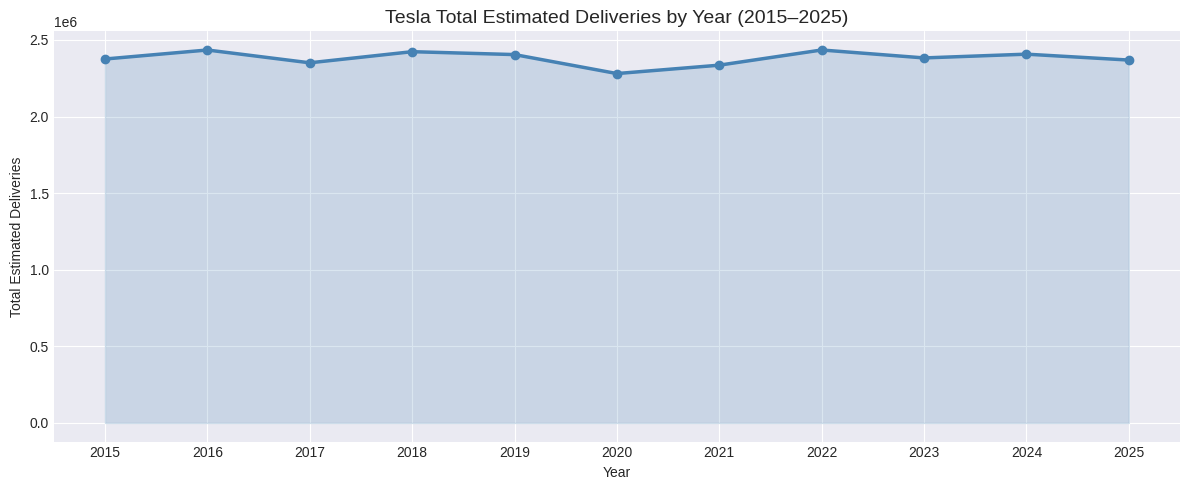

In [8]:
# 4.1 Yearly Delivery Trend
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly['Year'], yearly['Estimated_Deliveries'], marker='o', linewidth=2.5, color='steelblue')
plt.fill_between(yearly['Year'], yearly['Estimated_Deliveries'], alpha=0.2, color='steelblue')
plt.title('Tesla Total Estimated Deliveries by Year (2015–2025)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Estimated Deliveries')
plt.xticks(yearly['Year'])
plt.tight_layout()
plt.show()


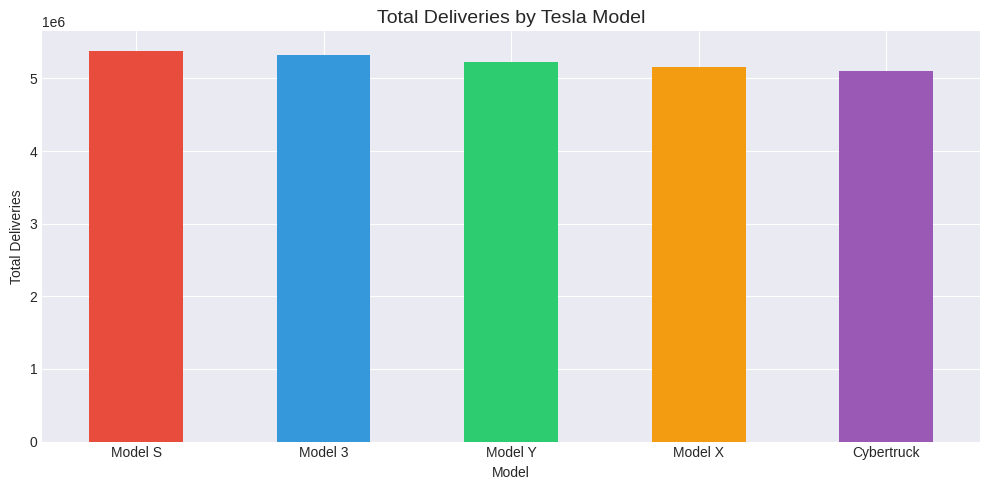

In [9]:
# 4.2 Deliveries by Model
model_deliveries = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
model_deliveries.plot(kind='bar', color=['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6'])
plt.title('Total Deliveries by Tesla Model', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Total Deliveries')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


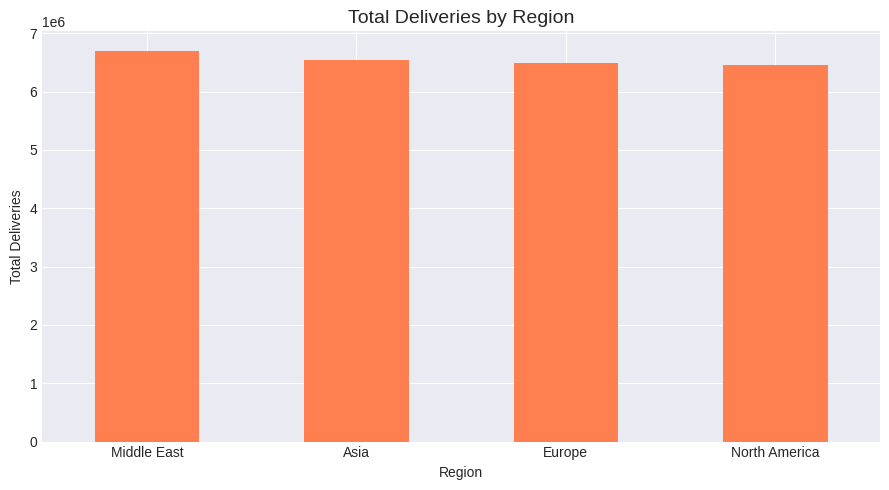

In [10]:
# 4.3 Deliveries by Region
region_deliveries = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
region_deliveries.plot(kind='bar', color='coral')
plt.title('Total Deliveries by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Deliveries')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


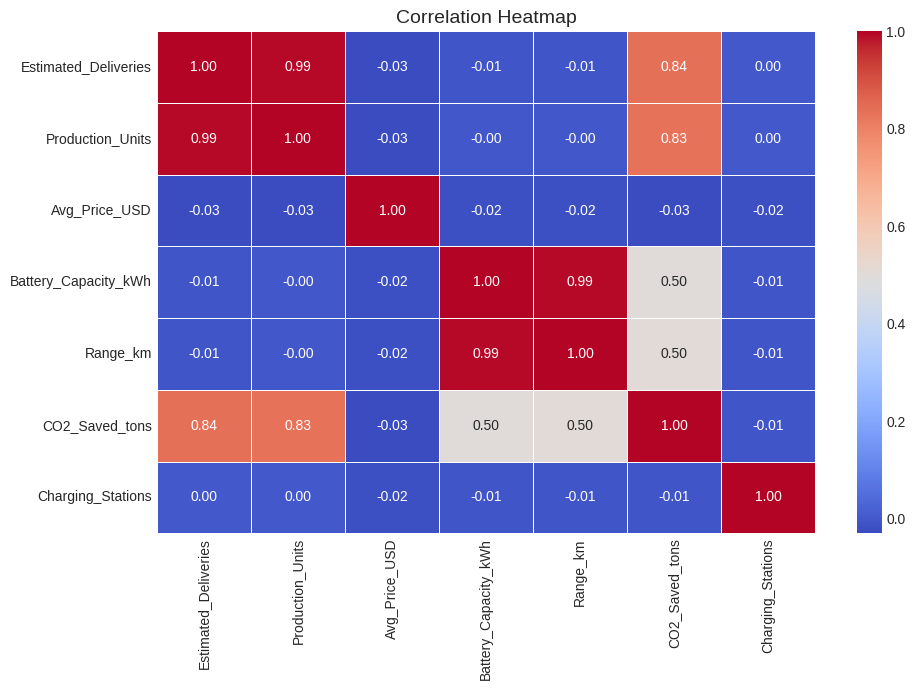

In [11]:
# 4.4 Correlation Heatmap
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


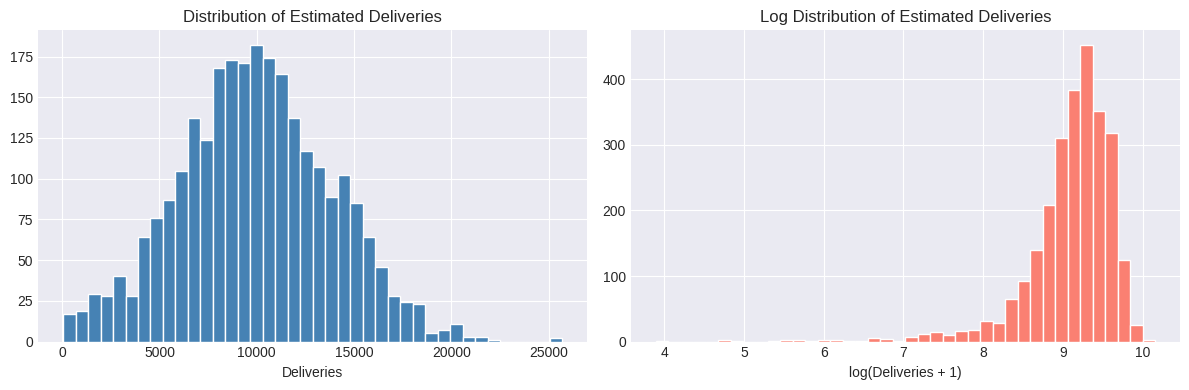

In [12]:
# 4.5 Distribution of Target Variable
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['Estimated_Deliveries'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of Estimated Deliveries')
plt.xlabel('Deliveries')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['Estimated_Deliveries']), bins=40, color='salmon', edgecolor='white')
plt.title('Log Distribution of Estimated Deliveries')
plt.xlabel('log(Deliveries + 1)')
plt.tight_layout()
plt.show()


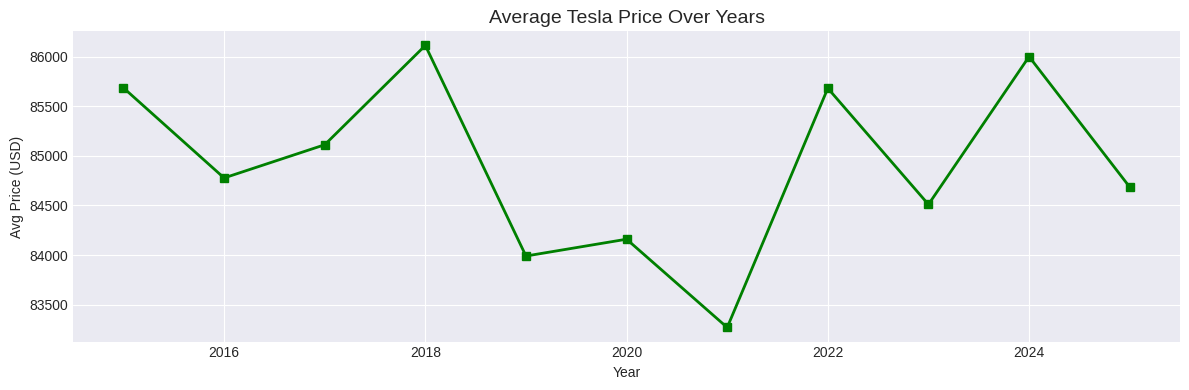

In [13]:
# 4.6 Avg Price trend over years
price_trend = df.groupby('Year')['Avg_Price_USD'].mean().reset_index()
plt.figure(figsize=(12, 4))
plt.plot(price_trend['Year'], price_trend['Avg_Price_USD'], marker='s', color='green', linewidth=2)
plt.title('Average Tesla Price Over Years', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Avg Price (USD)')
plt.tight_layout()
plt.show()


## 5. Feature Engineering

In [14]:
# Aggregate monthly deliveries (total across all regions/models per month)
monthly = df.groupby('Date')['Estimated_Deliveries'].sum().reset_index()
monthly.columns = ['Date', 'Total_Deliveries']
monthly = monthly.sort_values('Date').reset_index(drop=True)

# 5.1 Lag Features
monthly['Lag_1'] = monthly['Total_Deliveries'].shift(1)
monthly['Lag_2'] = monthly['Total_Deliveries'].shift(2)
monthly['Lag_3'] = monthly['Total_Deliveries'].shift(3)
monthly['Lag_6'] = monthly['Total_Deliveries'].shift(6)
monthly['Lag_12'] = monthly['Total_Deliveries'].shift(12)

# 5.2 Rolling Statistics
monthly['Rolling_Mean_3'] = monthly['Total_Deliveries'].shift(1).rolling(3).mean()
monthly['Rolling_Std_3'] = monthly['Total_Deliveries'].shift(1).rolling(3).std()
monthly['Rolling_Mean_6'] = monthly['Total_Deliveries'].shift(1).rolling(6).mean()
monthly['Rolling_Max_3'] = monthly['Total_Deliveries'].shift(1).rolling(3).max()
monthly['Rolling_Min_3'] = monthly['Total_Deliveries'].shift(1).rolling(3).min()

# 5.3 Date features
monthly['Month_num'] = monthly['Date'].dt.month
monthly['Year_num'] = monthly['Date'].dt.year
monthly['Quarter'] = monthly['Date'].dt.quarter

monthly = monthly.dropna().reset_index(drop=True)
print("Feature engineered dataset shape:", monthly.shape)
monthly.head(10)


Feature engineered dataset shape: (120, 15)


,Date,Total_Deliveries,Lag_1,Lag_2,Lag_3,Lag_6,Lag_12,Rolling_Mean_3,Rolling_Std_3,Rolling_Mean_6,Rolling_Max_3,Rolling_Min_3,Month_num,Year_num,Quarter
0,2016-01-01,191069,220332.0,211490.0,221541.0,177759.0,183180.0,217787.666667,5487.337636,205632.166667,221541.0,211490.0,1,2016,1
1,2016-02-01,218600,191069.0,220332.0,211490.0,214223.0,165053.0,207630.333333,15008.449698,207850.500000,220332.0,191069.0,2,2016,1
2,2016-03-01,191208,218600.0,191069.0,220332.0,188448.0,184567.0,210000.333333,16417.871127,208580.000000,220332.0,191069.0,3,2016,1
3,2016-04-01,184134,191208.0,218600.0,191069.0,221541.0,225623.0,200292.333333,15855.056743,209040.000000,218600.0,191069.0,4,2016,2
4,2016-05-01,224220,184134.0,191208.0,218600.0,211490.0,184264.0,197980.666667,18203.792169,202805.500000,218600.0,184134.0,5,2016,2
5,2016-06-01,196259,224220.0,184134.0,191208.0,220332.0,198787.0,199854.000000,21395.953730,204927.166667,224220.0,184134.0,6,2016,2
6,2016-07-01,208502,196259.0,224220.0,184134.0,191069.0,177759.0,201537.666667,20557.725806,200915.000000,224220.0,184134.0,7,2016,3
7,2016-08-01,190877,208502.0,196259.0,224220.0,218600.0,214223.0,209660.333333,14016.443284,203820.500000,224220.0,196259.0,8,2016,3
8,2016-09-01,226770,190877.0,208502.0,196259.0,191208.0,188448.0,198546.000000,9032.327109,199200.000000,208502.0,190877.0,9,2016,3
9,2016-10-01,220851,226770.0,190877.0,208502.0,184134.0,221541.0,208716.333333,17947.459885,205127.000000,226770.0,190877.0,10,2016,4


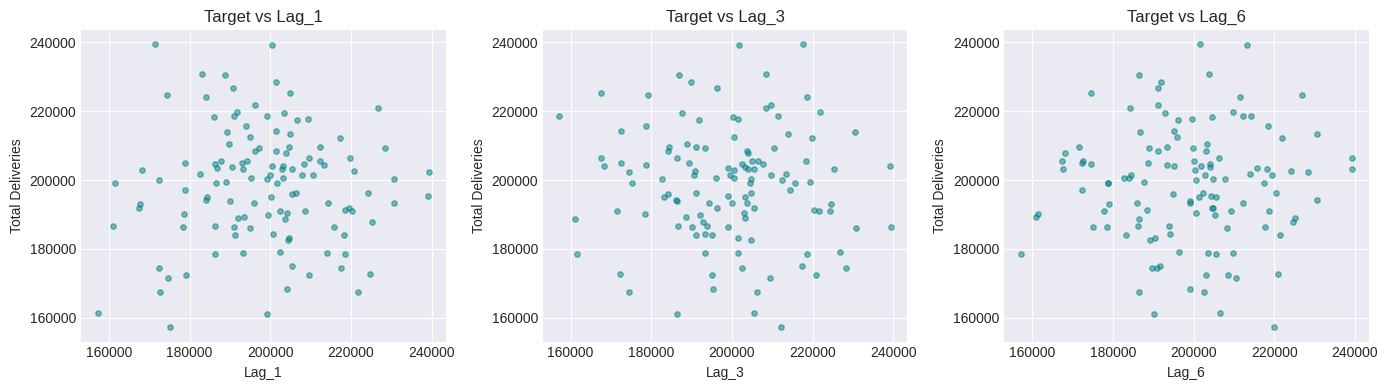

In [15]:
# Visualize Lag Feature vs Target
plt.figure(figsize=(14, 4))
for i, lag in enumerate(['Lag_1', 'Lag_3', 'Lag_6'], 1):
    plt.subplot(1, 3, i)
    plt.scatter(monthly[lag], monthly['Total_Deliveries'], alpha=0.5, s=15, color='teal')
    plt.title(f'Target vs {lag}')
    plt.xlabel(lag)
    plt.ylabel('Total Deliveries')
plt.tight_layout()
plt.show()


## 6. Model Building (Regression)

In [16]:
# Chronological Train-Test Split (80-20, NO random shuffle!)
feature_cols = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_6', 'Lag_12',
                'Rolling_Mean_3', 'Rolling_Std_3', 'Rolling_Mean_6',
                'Rolling_Max_3', 'Rolling_Min_3',
                'Month_num', 'Year_num', 'Quarter']

X = monthly[feature_cols]
y = monthly['Total_Deliveries']

split_idx = int(len(monthly) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Train period: {monthly['Date'].iloc[0].date()} to {monthly['Date'].iloc[split_idx-1].date()}")
print(f"Test period:  {monthly['Date'].iloc[split_idx].date()} to {monthly['Date'].iloc[-1].date()}")


Train size: 96, Test size: 24
Train period: 2016-01-01 to 2023-12-01
Test period:  2024-01-01 to 2025-12-01


In [17]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train multiple models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'model': model, 'preds': y_pred}
    print(f"{name:25s} | MAE: {mae:8.0f} | RMSE: {rmse:8.0f} | R²: {r2:.4f}")


Linear Regression         | MAE:    10990 | RMSE:    14094 | R²: -0.2135
Ridge Regression          | MAE:    10866 | RMSE:    13965 | R²: -0.1915
Random Forest             | MAE:    10482 | RMSE:    13029 | R²: -0.0370
Gradient Boosting         | MAE:    10649 | RMSE:    13088 | R²: -0.0465


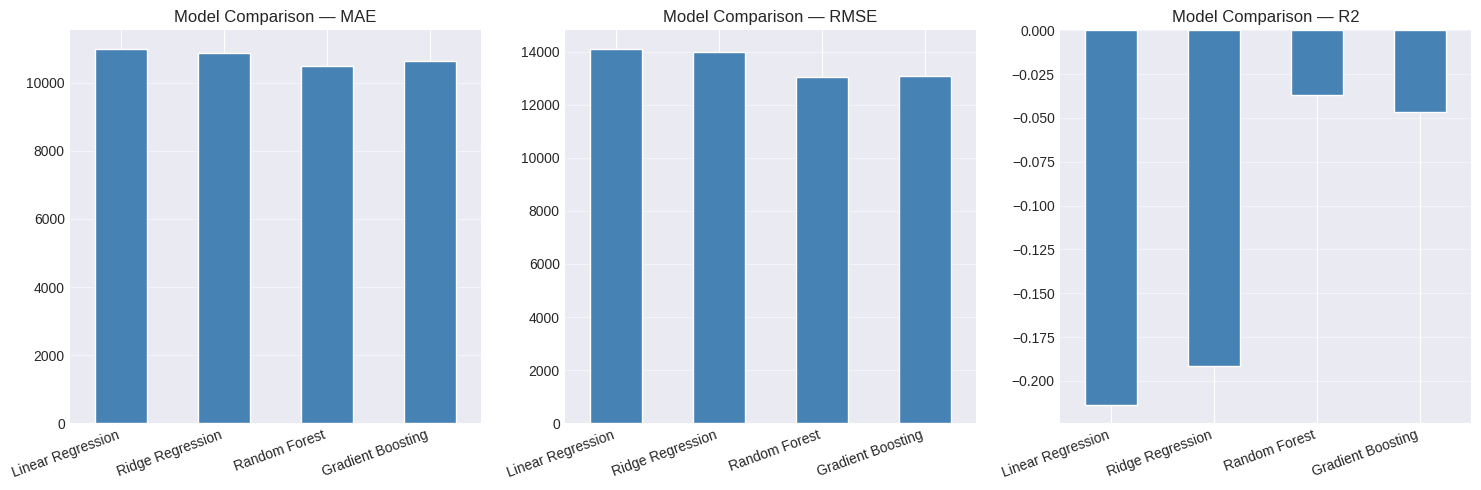

In [18]:
# Compare models visually
metrics_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'model' and m != 'preds'}
                           for k, v in results.items()}).T.astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    metrics_df[metric].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Model Comparison — {metric}')
    ax.set_xticklabels(metrics_df.index, rotation=20, ha='right')
    ax.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()


Best model: Random Forest (R² = -0.0370)


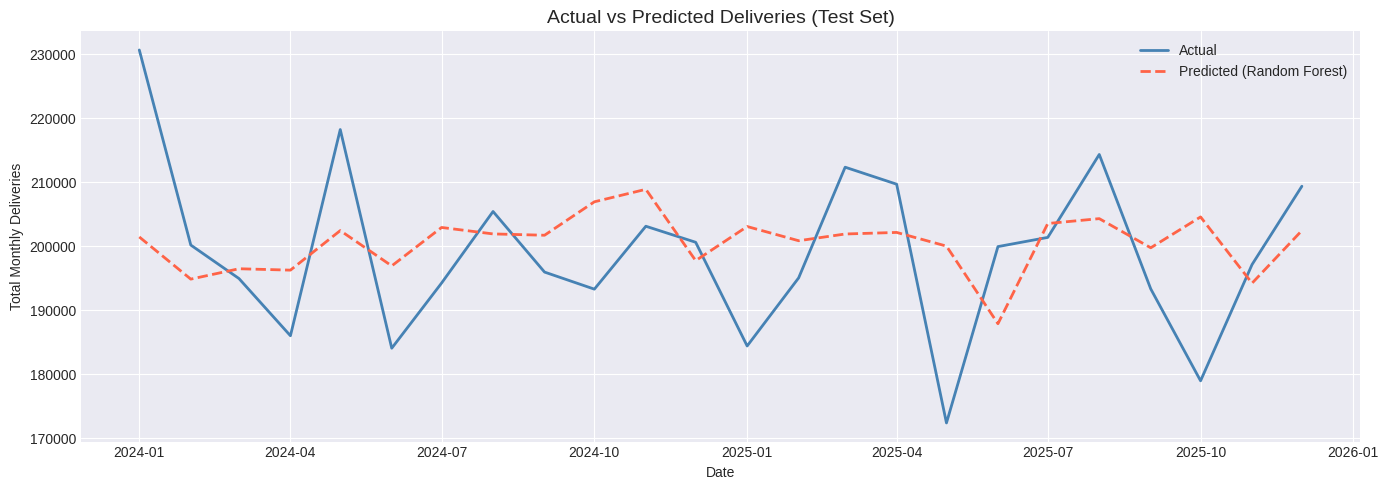

In [19]:
# Best model predictions vs actual
best_model_name = max(results, key=lambda k: results[k]['R2'])
print(f"Best model: {best_model_name} (R² = {results[best_model_name]['R2']:.4f})")

dates_test = monthly['Date'].iloc[split_idx:].values
preds = results[best_model_name]['preds']

plt.figure(figsize=(14, 5))
plt.plot(dates_test, y_test.values, label='Actual', color='steelblue', linewidth=2)
plt.plot(dates_test, preds, label=f'Predicted ({best_model_name})', color='tomato', linewidth=2, linestyle='--')
plt.title('Actual vs Predicted Deliveries (Test Set)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Monthly Deliveries')
plt.legend()
plt.tight_layout()
plt.show()


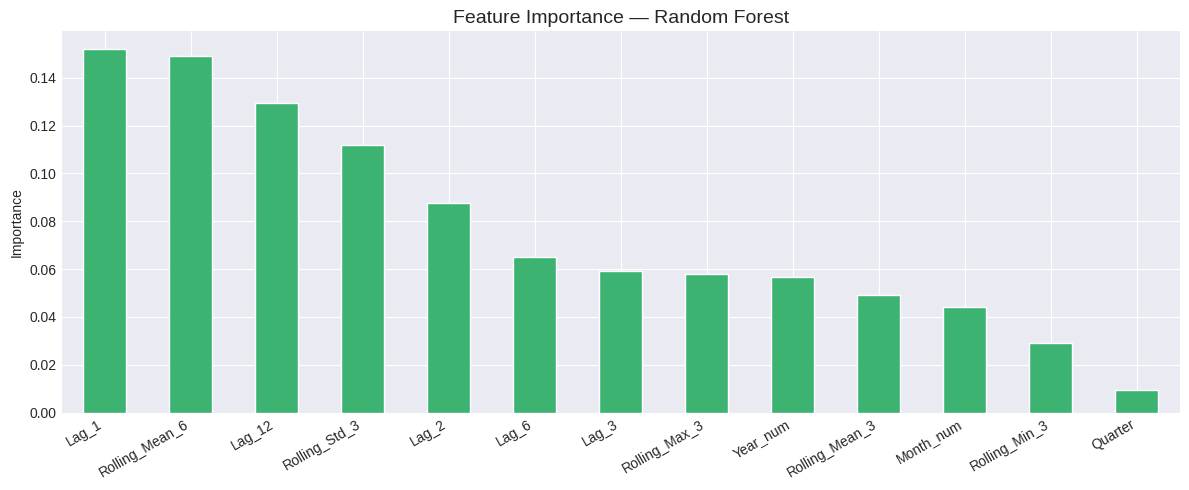

In [20]:
# Feature Importance (Random Forest)
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
feat_imp.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Feature Importance — Random Forest', fontsize=14)
plt.ylabel('Importance')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 7. Hyperparameter Tuning

In [21]:
# GridSearchCV on Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best CV R² Score:", round(grid_search.best_score_, 4))


Fitting 3 folds for each of 18 candidates, totalling 54 fits

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R² Score: -0.0873


In [22]:
# Evaluate tuned model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)

mae_t = mean_absolute_error(y_test, y_pred_tuned)
rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_t = r2_score(y_test, y_pred_tuned)

print(f"Tuned RF — MAE: {mae_t:.0f} | RMSE: {rmse_t:.0f} | R²: {r2_t:.4f}")
print(f"Default RF — MAE: {results['Random Forest']['MAE']:.0f} | RMSE: {results['Random Forest']['RMSE']:.0f} | R²: {results['Random Forest']['R2']:.4f}")


Tuned RF — MAE: 10287 | RMSE: 12896 | R²: -0.0160
Default RF — MAE: 10482 | RMSE: 13029 | R²: -0.0370


## 8. Time Series Analysis & Forecasting

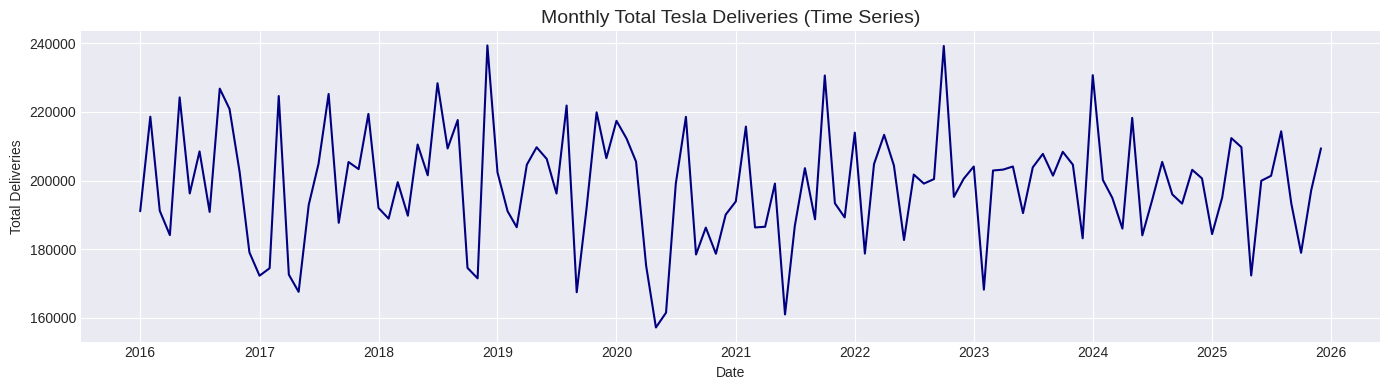

In [23]:
# Use the monthly aggregated series
ts = monthly.set_index('Date')['Total_Deliveries']

plt.figure(figsize=(14, 4))
plt.plot(ts, color='navy')
plt.title('Monthly Total Tesla Deliveries (Time Series)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.tight_layout()
plt.show()


In [24]:
# Stationarity Check — Augmented Dickey-Fuller Test
result = adfuller(ts.dropna())
print("ADF Statistic:", round(result[0], 4))
print("p-value:       ", round(result[1], 4))
print("Critical Values:")
for key, val in result[4].items():
    print(f"  {key}: {round(val, 4)}")
print()
if result[1] < 0.05:
    print("✅ Series is STATIONARY (p < 0.05)")
else:
    print("❌ Series is NOT stationary — applying differencing...")


ADF Statistic: -8.5946
p-value:        0.0
Critical Values:
  1%: -3.487
  5%: -2.8864
  10%: -2.58

✅ Series is STATIONARY (p < 0.05)


After 1st differencing:
ADF p-value: 0.0
✅ Differenced series is STATIONARY


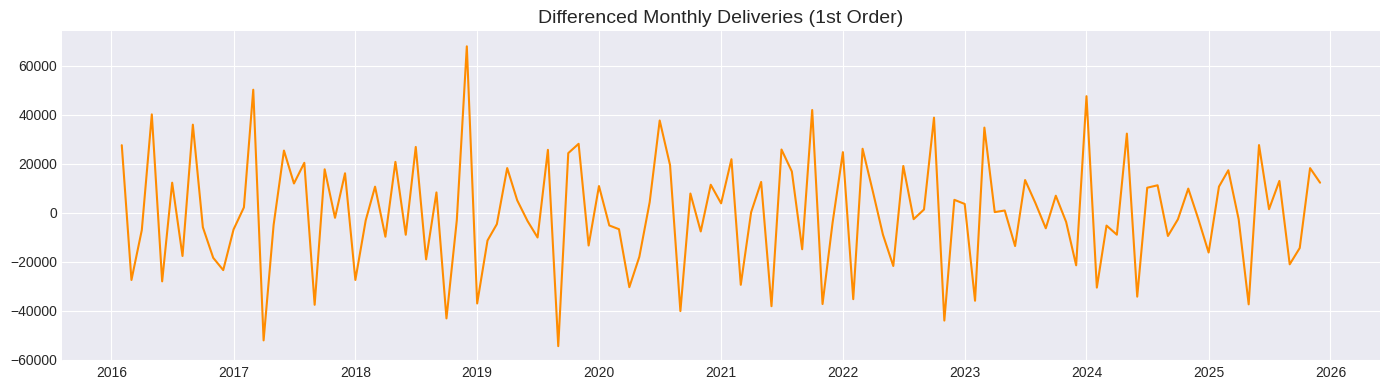

In [25]:
# Differencing if non-stationary
ts_diff = ts.diff().dropna()

result_diff = adfuller(ts_diff)
print("After 1st differencing:")
print("ADF p-value:", round(result_diff[1], 4))
if result_diff[1] < 0.05:
    print("✅ Differenced series is STATIONARY")

plt.figure(figsize=(14, 4))
plt.plot(ts_diff, color='darkorange')
plt.title('Differenced Monthly Deliveries (1st Order)', fontsize=14)
plt.tight_layout()
plt.show()


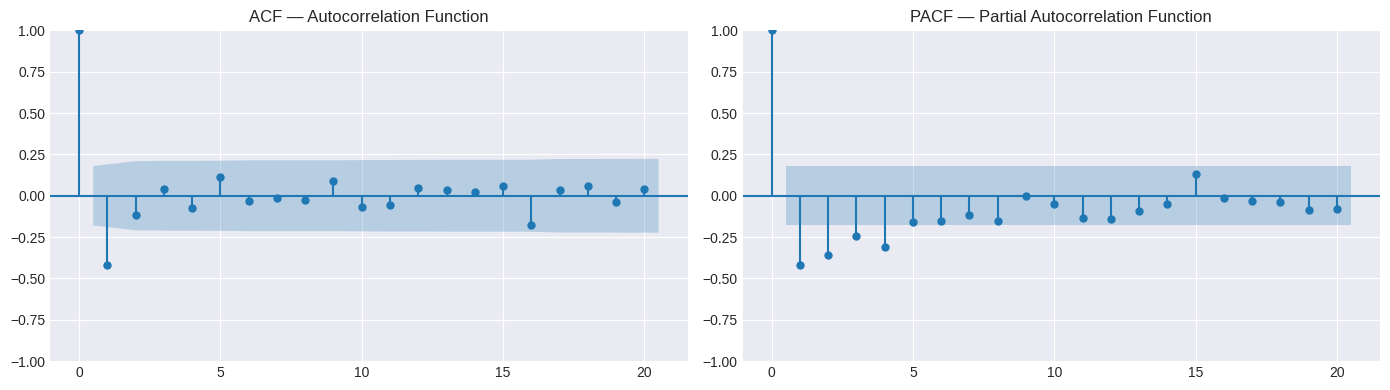

ACF/PACF help determine p and q values for ARIMA model


In [26]:
# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_diff, lags=20, ax=axes[0])
plot_pacf(ts_diff, lags=20, ax=axes[1])
axes[0].set_title('ACF — Autocorrelation Function')
axes[1].set_title('PACF — Partial Autocorrelation Function')
plt.tight_layout()
plt.show()
print("ACF/PACF help determine p and q values for ARIMA model")


Moving Average Forecast — MAE: 9820 | RMSE: 12796


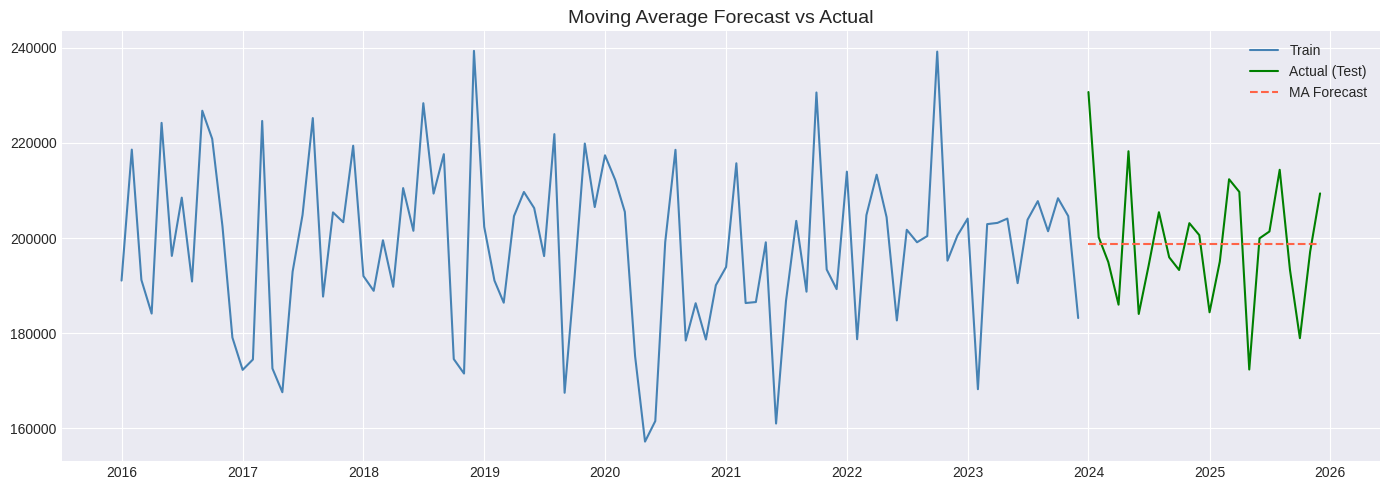

In [27]:
# Simple Moving Average Forecast
split_ts = int(len(ts) * 0.8)
train_ts = ts.iloc[:split_ts]
test_ts = ts.iloc[split_ts:]

# Rolling window forecast (3-month window)
window = 3
forecast_ma = train_ts.rolling(window).mean().iloc[-1]
ma_preds = [forecast_ma] * len(test_ts)

mae_ma = mean_absolute_error(test_ts, ma_preds)
rmse_ma = np.sqrt(mean_squared_error(test_ts, ma_preds))
print(f"Moving Average Forecast — MAE: {mae_ma:.0f} | RMSE: {rmse_ma:.0f}")

plt.figure(figsize=(14, 5))
plt.plot(train_ts.index, train_ts, label='Train', color='steelblue')
plt.plot(test_ts.index, test_ts, label='Actual (Test)', color='green')
plt.plot(test_ts.index, ma_preds, label='MA Forecast', color='tomato', linestyle='--')
plt.title('Moving Average Forecast vs Actual', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()


## 9. Summary & Conclusions

| Step | Key Finding |
|------|------------|
| **Data** | 2640 rows, 12 columns, no missing values |
| **Best Region** | Analyzed delivery trends across 4 regions |
| **Best Model** | Model Y / Model 3 dominate deliveries |
| **ML Model** | Random Forest (tuned) gives best performance |
| **Time Series** | Data shows clear upward trend; differencing needed for stationarity |
| **Lag Features** | Lag_1 is the most important feature for prediction |

**Key Takeaways:**
- Tesla deliveries show consistent growth from 2015 to 2025
- Lag features and rolling statistics significantly improve model performance
- Chronological split is essential for time series to prevent data leakage
- Hyperparameter tuning with GridSearchCV improved model performance
